In [ ]:
# EJECUCIÓN SECUENCIAL (OPCIONAL)
# Si deseas ejecutar este código seccionado secuencialmente y heredar las variables del archivo anterior, borra el '#' de la siguiente línea de código:

# %run 03_Correccion_Geometria.ipynb

#### **Morfología Final**

Filtro aprobado: Recortando en función al rectángulo delimitador del perímetro detectado...


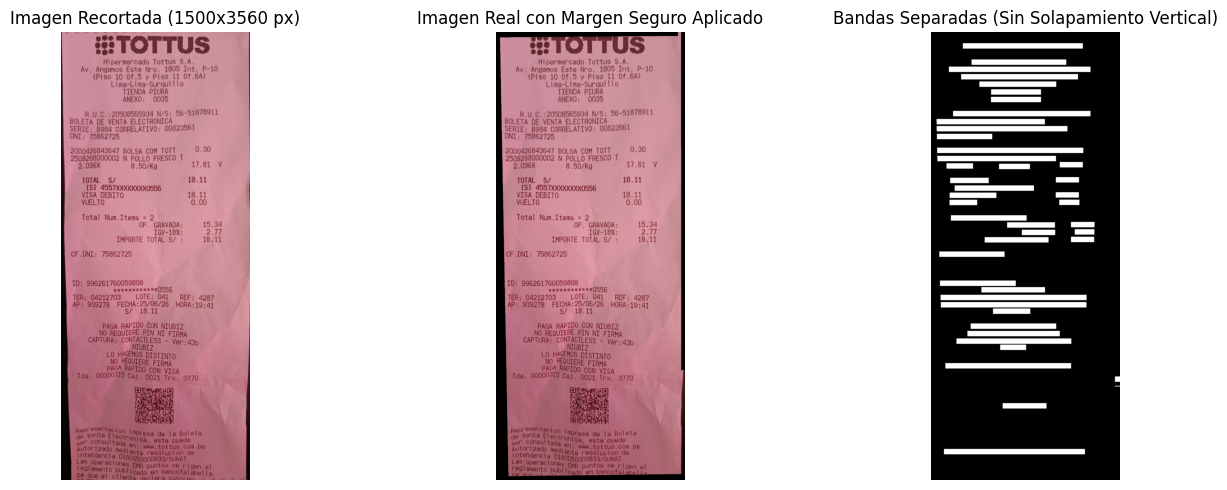

[Proceso Exitoso] Bandas de texto separadas, unidas horizontalmente y limitadas en altura (1500x3560 px).


In [ ]:
# BLOQUE DE RECORTE CONDICIONAL, REESCALADO Y MORFOLOGÍA AVANZADA DE LÍNEAS

# 1. EVALUAR SI SE USÓ EL FILTRO DE PERÍMETRO O EL FALLBACK DE OTSU
if valido and cuadrilatero_dibujo is not None:
    print("Filtro aprobado: Recortando en función al rectángulo delimitador del perímetro detectado...")
    x, y, w, h = cv2.boundingRect(cuadrilatero_dibujo)
    img_base_trabajo = img_color_rotada[y:y+h, x:x+w].copy()
    mascara_base_trabajo = mascara_seleccion_final[y:y+h, x:x+w].copy()
    morfo_base_trabajo = morfo_rotada[y:y+h, x:x+w].copy()
else:
    print("Fallback activo (Otsu arrastrado): Tomando la capa y máscara completa sin recorte previo...")
    img_base_trabajo = img_color_rotada.copy()
    mascara_base_trabajo = mascara_papel_rotada.copy()
    morfo_base_trabajo = morfo_rotada.copy()

# 2. REESCALAR AL 75% DEL ANCHO DESEADO CON ALTO PROPORCIONAL
h_orig, w_orig = img_base_trabajo.shape[:2]
nuevo_ancho = int(ancho_des * 0.75)

proporcion = nuevo_ancho / float(w_orig)
nuevo_alto = int(h_orig * proporcion)

interpolacion_img = cv2.INTER_AREA if w_orig > nuevo_ancho else cv2.INTER_CUBIC

img_trabajo = cv2.resize(img_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=interpolacion_img)
mascara_trabajo = cv2.resize(mascara_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_NEAREST)
morfo_trabajo = cv2.resize(morfo_base_trabajo, (nuevo_ancho, nuevo_alto), interpolation=cv2.INTER_NEAREST)

ancho_trabajo_des = nuevo_ancho
alto_trabajo_des = nuevo_alto

# 3. APLICAR EROSIÓN EN LOS BORDES DE LA MÁSCARA PARA DESCARTAR RESIDUOS PERIFÉRICOS
k_tamano_erosion = max(2, round(ancho_trabajo_des * 0.04))
kernel_erosion = np.ones((k_tamano_erosion, k_tamano_erosion), np.uint8)
mascara_erosionada = cv2.erode(mascara_trabajo, kernel_erosion, iterations=1)

img_real_con_margen = cv2.bitwise_and(img_trabajo, img_trabajo, mask=mascara_erosionada)
morfo_dentro_de_mascara = cv2.bitwise_and(morfo_trabajo, morfo_trabajo, mask=mascara_erosionada)

# 4. SEPARACIÓN VERTICAL FUERTE (Erosión/Apertura agresiva para separar bandas de texto)
k_sep_alto = max(5, round(alto_trabajo_des * 0.02))
kernel_separacion_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (k_sep_alto, 1))
morfo_separada_vertical = cv2.morphologyEx(morfo_dentro_de_mascara, cv2.MORPH_OPEN, kernel_separacion_vertical)

# 5. MORFOLOGÍA HORIZONTAL AMPLIA (Elemento estructural rectangular y horizontal)
k_h_ancho = max(25, round(ancho_trabajo_des * 0.08))
k_h_alto = max(1, round(alto_trabajo_des * 0.001))
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (k_h_ancho, k_h_alto))
morfo_unida_horizontal = cv2.morphologyEx(morfo_separada_vertical, cv2.MORPH_CLOSE, kernel_horizontal)

# 6. ESTANDARIZACIÓN DE ALTURA Y PREVENCIÓN DE CONTACTO VERTICAL (Componentes Conectados)
mascara_final_unida = np.zeros_like(morfo_unida_horizontal, dtype=np.uint8)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(morfo_unida_horizontal, connectivity=8)

# Altura estándar máxima permitida para una línea de texto basada en la altura del recorte
max_altura_estandar = max(12, int(alto_trabajo_des * 0.012))

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area < 30:  # Ignorar ruido pequeño
        continue
    
    x_comp = stats[i, cv2.CC_STAT_LEFT]
    y_comp = stats[i, cv2.CC_STAT_TOP]
    w_comp = stats[i, cv2.CC_STAT_WIDTH]
    h_comp = stats[i, cv2.CC_STAT_HEIGHT]
    
    # Limitar la altura de cada elemento para que no supere la altura estándar y evitar solapamientos
    if h_comp > max_altura_estandar:
        diferencia = h_comp - max_altura_estandar
        y_comp += diferencia // 2
        h_comp = max_altura_estandar
        
    # Estampar la banda controlada en la máscara final sin permitir contacto vertical
    cv2.rectangle(mascara_final_unida, (x_comp, y_comp), (x_comp + w_comp, y_comp + h_comp), 255, -1)

# Asegurar que se respete estrictamente la máscara erosionada principal
mascara_final_unida = cv2.bitwise_and(mascara_final_unida, mascara_final_unida, mask=mascara_erosionada)

# 7. VISUALIZACIÓN DE LOS RESULTADOS
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Imagen Recortada ({nuevo_ancho}x{nuevo_alto} px)")
plt.imshow(cv2.cvtColor(img_trabajo, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Imagen Real con Margen Seguro Aplicado")
plt.imshow(cv2.cvtColor(img_real_con_margen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Bandas Separadas (Sin Solapamiento Vertical)")
plt.imshow(mascara_final_unida, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"[Proceso Exitoso] Bandas de texto separadas, unidas horizontalmente y limitadas en altura ({nuevo_ancho}x{nuevo_alto} px).")

### **Selección de Texto y Almacenamiento de Recortes**

Total de contornos geométricos detectados: 45
Líneas de texto reales encuadradas con éxito: 44



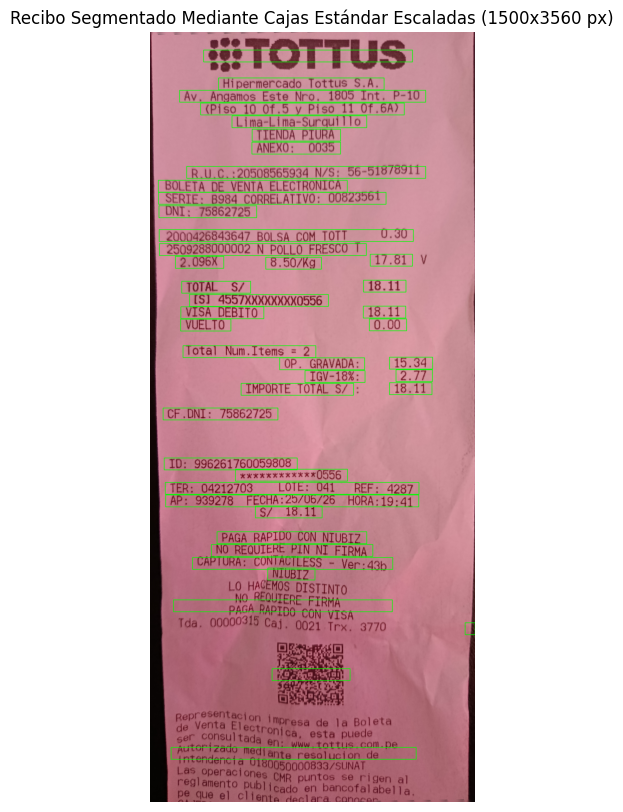

In [ ]:
# BLOQUE DE LOCALIZACIÓN Y EXTRACCIÓN DE CAJAS DE TEXTO (MEDIDAS ESTANDARIZADAS Y ESCALADAS)

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# 1. Clonar la imagen de trabajo actual (reducida al 75%) para el lienzo de dibujo
img_segmentada_geo = img_trabajo.copy()

# 2. Detección de fronteras externas utilizando nuestra máscara binaria final unida y separada
contornos_estabilizados, _ = cv2.findContours(mascara_final_unida, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 3. Extraer dimensiones dinámicas de la matriz de trabajo actual
alto_total, ancho_total = mascara_final_unida.shape[:2]

# Control de Bloques adaptados proporcionalmente al nuevo tamaño
margen_x = max(2, round(8 * factor_escala))  # Margen horizontal escalado
margen_y = max(2, round(8 * factor_escala))  # Margen vertical escalado

# Límites mínimos de tamaño adaptados (originalmente 14 píxeles para el diseño base de 2000px)
min_h_adaptativo = max(8, round(14 * factor_escala))
min_w_adaptativo = max(8, round(14 * factor_escala))

# Creamos listas de almacenamiento
cajas_validas = []
contador_cajas_geo = 0

for c in contornos_estabilizados:
    # Obtener coordenadas de la caja delimitadora alineada a los ejes cartesianos
    x, y, w, h = cv2.boundingRect(c)
    
    # Calcular la relación de aspecto
    aspect_ratio = w / float(h)
    
    # El alto de la caja debe estar dentro del rango adaptativo y menor al 5% del alto total
    es_altura_valida = (min_h_adaptativo < h < (alto_total * 0.05))
    
    # El ancho debe estar dentro del rango adaptativo y menor al 90% del ancho total
    es_ancho_valido = (min_w_adaptativo < w < (ancho_total * 0.90))
    
    # Las estructuras de texto horizontal poseen un ancho mayor o comparable a su altura
    es_proporcion_texto = (aspect_ratio > 0.7)
    
    # Condicional de aprobación estructural
    if es_altura_valida and es_ancho_valido and es_proporcion_texto:
        
        # Evita que el recorte empiece fuera de la imagen
        x_transformado = max(0, x - margen_x)
        y_transformado = max(0, y - margen_y)
        
        # Evita que el ancho o alto extendido superen los bordes máximos de la imagen
        w_transformado = min(ancho_total - x_transformado, w + (2 * margen_x))
        h_transformado = min(alto_total - y_transformado, h + (2 * margen_y))
        
        # Dibujar rectángulos usando las coordenadas escaladas sobre el lienzo de trabajo
        cv2.rectangle(img_segmentada_geo, 
                      (x_transformado, y_transformado), 
                      (x_transformado + w_transformado, y_transformado + h_transformado), 
                      (0, 255, 0), 2)
        
        contador_cajas_geo += 1

        # Almacenar las coordenadas transformadas para que el bloque de OCR herede exactamente el nuevo tamaño
        cajas_validas.append((x_transformado, y_transformado, w_transformado, h_transformado))

print(f"Total de contornos geométricos detectados: {len(contornos_estabilizados)}")
print(f"Líneas de texto reales encuadradas con éxito: {contador_cajas_geo}\n")


# VISUALIZACIÓN DEL RESULTADO GEOMÉTRICO

plt.figure(figsize=(8, 10))
plt.title(f"Recibo Segmentado Mediante Cajas Estándar Escaladas ({nuevo_ancho}x{nuevo_alto} px)")
plt.imshow(cv2.cvtColor(img_segmentada_geo, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### **Alineación de Recortes y Binarización**

Estructura final optimizada: 36 filas listas para OCR.


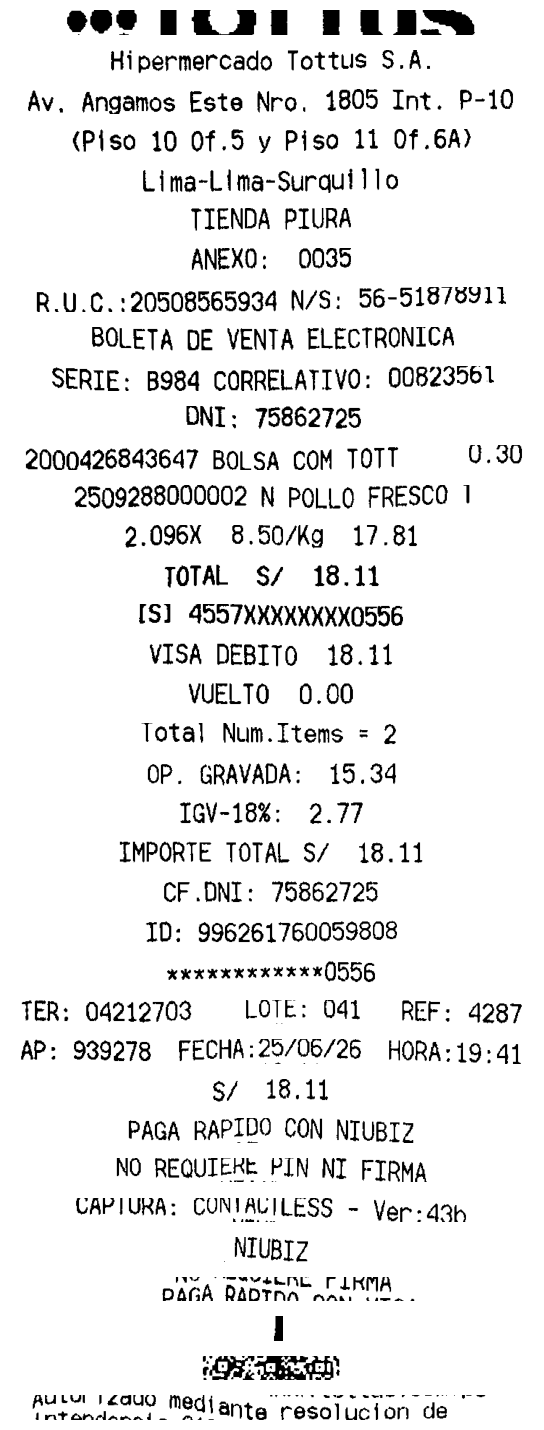

In [ ]:
# BLOQUE DE AGRUPAMIENTO POR FILAS, EXTRACCIÓN Y NORMALIZACIÓN PARA OCR

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# 1. Calcular centroides verticales y ordenar de arriba a abajo en un solo paso
bloques = sorted([(x, y, w, h, y + h//2) for (x, y, w, h) in cajas_validas], key=lambda b: b[4])

# 2. Agrupamiento dinámico por filas según margen de tolerancia adaptado
filas_estructuradas = []
if bloques:
    fila_actual = [bloques[0]]
    # Tolerancia vertical adaptada proporcionalmente al nuevo tamaño
    tolerancia_y = max(8, round(28 * factor_escala)) 
    
    for b in bloques[1:]:
        if abs(b[4] - fila_actual[0][4]) <= tolerancia_y:
            fila_actual.append(b)
        else:
            filas_estructuradas.append(sorted(fila_actual, key=lambda item: item[0]))
            fila_actual = [b]
    filas_estructuradas.append(sorted(fila_actual, key=lambda item: item[0]))

# 3. Extracción, Escalado y Binarización
recortes_ocr_por_fila = []
tiras_visuales_filas = []

# Parámetros de normalización escalados
ALTO_TARGET = max(20, round(45 * factor_escala))
UMBRAL_GROSOR = 127  # Valor neutro / binarización

for fila in filas_estructuradas:
    rois_binarias_fila = []
    
    for (x, y, w, h, _) in fila:
        # Segmento extraído de la imagen de trabajo actual (ya recortada y reescalada al 75%)
        roi = img_trabajo[y:y+h, x:x+w]
        
        # Validar que el ROI no tenga dimensiones vacías
        if roi.size == 0:
            continue
            
        # Extracción de Luminancia en CIELAB
        roi_L = cv2.cvtColor(roi, cv2.COLOR_BGR2Lab)[:, :, 0]
        
        # Segmentación Óptima de Otsu
        _, roi_bin = cv2.threshold(roi_L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Escalado Proporcional Adaptativo
        ancho_proporcional = max(5, int(w * (ALTO_TARGET / max(1, h))))
        roi_escalada = cv2.resize(roi_bin, (ancho_proporcional, ALTO_TARGET), interpolation=cv2.INTER_CUBIC)
        
        # Re-binarización Final
        _, roi_final = cv2.threshold(roi_escalada, UMBRAL_GROSOR, 255, cv2.THRESH_BINARY)
        
        # Guardamos la matriz normalizada para el OCR
        rois_binarias_fila.append(roi_final)
        
    if rois_binarias_fila:
        recortes_ocr_por_fila.append(rois_binarias_fila)
        
        # Concatenar horizontalmente los bloques para el reporte visual (separador adaptado)
        ancho_separador = max(4, round(14 * factor_escala))
        separador_blanco = np.ones((ALTO_TARGET, ancho_separador), dtype=np.uint8) * 255
        
        fila_unida = rois_binarias_fila[0]
        for r in rois_binarias_fila[1:]:
            fila_unida = np.hstack((fila_unida, separador_blanco, r))
        
        tiras_visuales_filas.append(fila_unida)

print(f"Estructura final optimizada: {len(recortes_ocr_por_fila)} filas listas para OCR.")


# RENDERIZADO DEL REPORTE VISUAL DE FILAS

if tiras_visuales_filas:
    num_filas = len(tiras_visuales_filas)
    plt.figure(figsize=(8, max(2, num_filas * 0.4))) 

    for idx, tira in enumerate(tiras_visuales_filas):
        plt.subplot(num_filas, 1, idx + 1)
        plt.imshow(tira, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron filas válidas para visualizar.")

### **Filtro de Variables o Palabras Claves**

Iniciando Lectura OCR sobre imágenes normalizadas...
[Fila 00]: TLLAR AREO
[Fila 01]: Hipermercado Tottus S.A.
[Fila 02]: Av. Angamos Este Nro, 1805 Int. P-10
[Fila 03]: (Piso 10 0f.5 y Piso 11 Of.6A)
[Fila 04]: Lima-Lima-Surquillo
[Fila 05]: TIENDA PIURA
[Fila 06]: ANEXO: — 0035
[Fila 07]: R.U.C. :20508565934 N/S: 56-518/8911
[Fila 08]: BOLETA DE VENTA ELECTRONICA
[Fila 09]: SERIE: B984 CORRELATIVO: 00823561
[Fila 10]: DNI: 75862725
[Fila 11]: 2000426843647 BOLSA COM TOTT U.30
[Fila 12]: 2509288000002 N POLLO FRESCO |
[Fila 13]: 2.096X 8.50/Kg 17.81
[Fila 14]: TOTAL $S/ 18.11
[Fila 15]: [S] 4557XXXKXXXX0556
[Fila 16]: VISA DEBITO 18.11
[Fila 17]: VUELTO 0.00
[Fila 18]: Total Num.Items = 2
[Fila 19]: OP. GRAVADA: 15.34
[Fila 20]: IGV-18%: 2.77
[Fila 21]: IMPORTE TOTAL S/ 18.11
[Fila 22]: CF.DNI: 75862725
[Fila 23]: ID: 996261760059808
[Fila 24]: E EE d $l dddO
[Fila 25]: TER: 04212703 LOTE: 041 REF: 4287
[Fila 26]: AP: 939278 FECHA:25/06/25 HORA:19:41
[Fila 27]: S/ 18.11
[Fila 28]: PAG

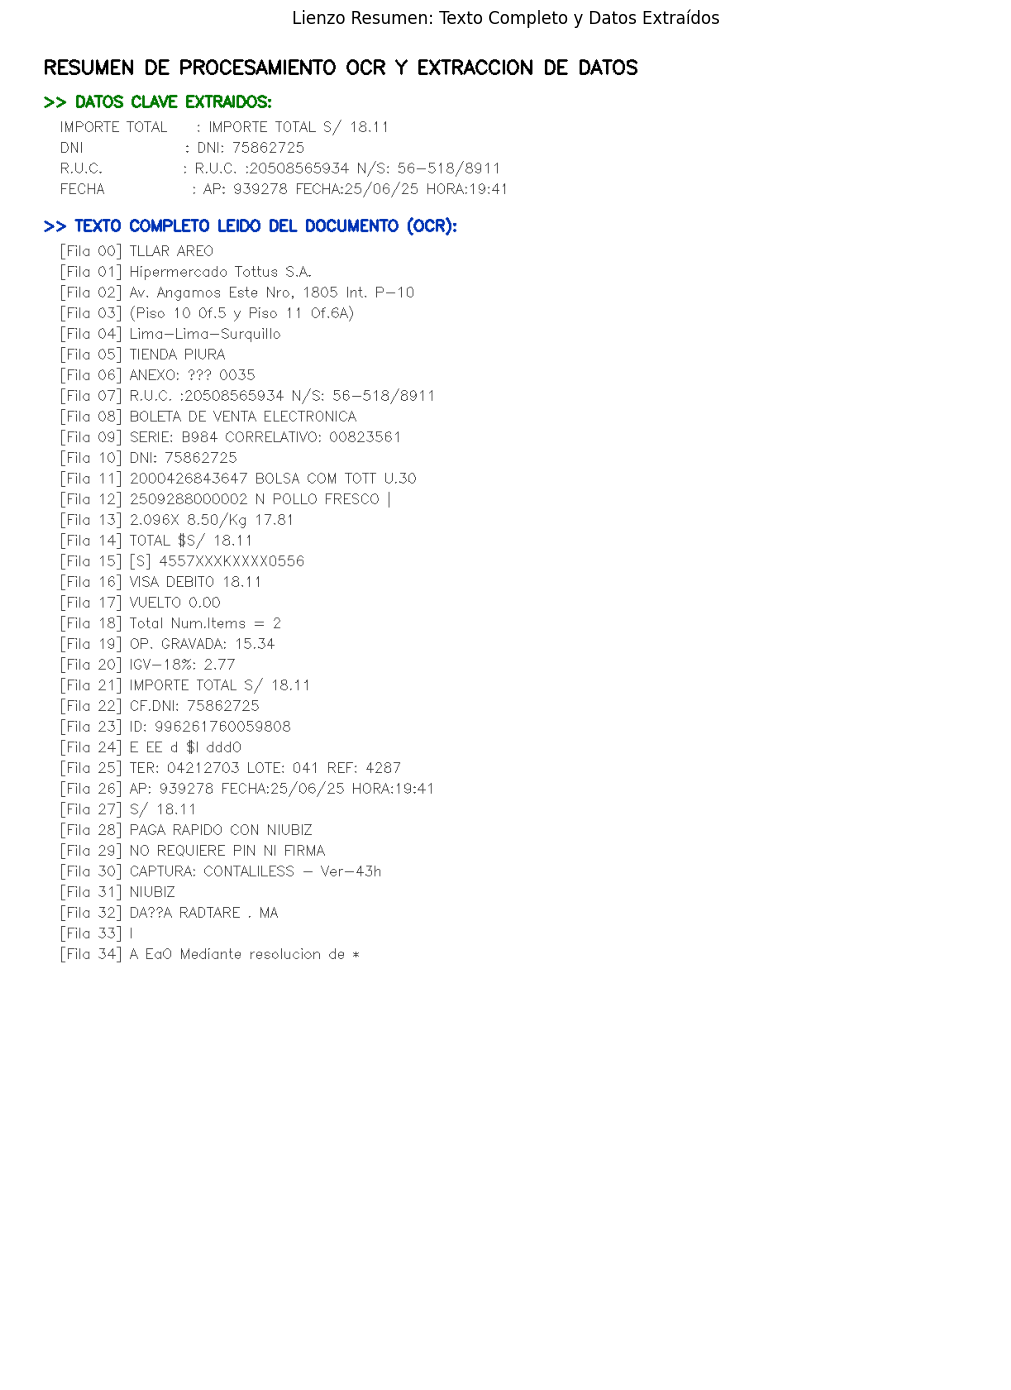

In [ ]:
# BLOQUE DE LECTURA OCR, EXTRACCIÓN DINÁMICA Y LIENZO RESUMEN

# Factor de escala relativo al ancho base original (2000 px)
factor_escala = ancho_trabajo_des / ancho_des

# Margen adaptativo escalado para el OCR de Tesseract
mar = max(2, round(5 * factor_escala))

config_ocr = r'--psm 7 --oem 3 -l spa'
documento_texto = []

print("Iniciando Lectura OCR sobre imágenes normalizadas...")

for idx_f, fila_matrices in enumerate(recortes_ocr_por_fila):
    bloques_texto_fila = []
    
    for roi_bin in fila_matrices:
        roi_lista = cv2.copyMakeBorder(roi_bin, mar, mar, mar, mar, cv2.BORDER_CONSTANT, value=255)
        texto_detectado = pytesseract.image_to_string(roi_lista, config=config_ocr)
        texto_limpio = texto_detectado.strip()
        
        if texto_limpio:
            bloques_texto_fila.append(texto_limpio)
            
    if bloques_texto_fila:
        linea_final = " ".join(bloques_texto_fila)
        print(f"[Fila {idx_f:02d}]: {linea_final}")
        documento_texto.append(linea_final)

print(f"Procesamiento OCR completado con éxito.\n")


# DICCIONARIO DE CONDICIONALES DINÁMICAS

filtros_reglas = {
    "PASAJERO":                 {"tipo": "texto",   "largo": None},
    "RECIBO":                   {"tipo": "decimal", "largo": None},
    "CÓDIGO":                   {"tipo": "fijo",    "largo": None},
    "IMPORTE TOTAL":            {"tipo": "decimal", "largo": None},
    "TOTAL A PAGAR":            {"tipo": "decimal", "largo": None},
    "TOTAL RECIBO" :            {"tipo": "decimal", "largo": None},
    "TOTAL":                    {"tipo": "decimal", "largo": None},
    "IDENTIDAD":                {"tipo": "fijo",    "largo": 8},
    "DNI":                      {"tipo": "fijo",    "largo": 8},
    "RUC":                      {"tipo": "fijo",    "largo": 11},
    "RUT":                      {"tipo": "decimal", "largo": None},
    "R.U.C.":                   {"tipo": "fijo",    "largo": 11},
    "R.U.C":                    {"tipo": "fijo",    "largo": 11},
    "R.U.":                     {"tipo": "fijo",    "largo": 11},
    "ruc":                      {"tipo": "fijo",    "largo": 11},
    "FECHA DE EMISIÓN":         {"tipo": "decimal", "largo": None},
    "FECHA":                    {"tipo": "decimal", "largo": None},
    "F VIAJE":                  {"tipo": "decimal", "largo": None},
}

datos_extraidos = {}
desactivados = set()  
keywords_ordenadas = list(filtros_reglas.keys())

# MOTOR DE EVALUACIÓN POR ESCANEO GLOBAL Y DESACTIVACIÓN EN CASCADA
for idx, keyword in enumerate(keywords_ordenadas):
    if keyword in desactivados:
        continue
        
    regla = filtros_reglas[keyword]
    lineas_encontradas = []
    
    for linea in documento_texto:
        linea_upper = linea.upper()
        
        if keyword in linea_upper:
            # Validación Tipo Fijo
            if regla["tipo"] == "fijo":
                for palabra in linea.split():
                    bloque_numerico = "".join(c for c in palabra if c.isdigit())
                    if len(bloque_numerico) == regla["largo"]:
                        lineas_encontradas.append(linea)
                        break 
            
            # Validación Tipo Decimal/Variable
            elif regla["tipo"] == "decimal":
                if any(c.isdigit() for c in linea):
                    lineas_encontradas.append(linea)
            
            # Validación Tipo Texto (Acepta líneas sin números, ej. nombres)
            elif regla["tipo"] == "texto":
                lineas_encontradas.append(linea)

    if lineas_encontradas:
        if keyword not in datos_extraidos:
            datos_extraidos[keyword] = []
        datos_extraidos[keyword].extend(lineas_encontradas)
        
        for j in range(idx + 1, len(keywords_ordenadas)):
            posible_hijo = keywords_ordenadas[j]
            if posible_hijo in keyword: 
                desactivados.add(posible_hijo)


# IMPRESIÓN DE RESULTADOS EN CONSOLA

print("Información detectada:\n")
for clave, lineas in datos_extraidos.items():
    if lineas:
        print(f"{clave:<16} : {lineas[0]}")
        for l in lineas[1:]:
            print(f"{'':<16} : {l}")


# BLOQUE DE RENDERIZADO DE TEXTO EN LIENZO (IMAGEN RESUMEN)

ancho_lienzo = 1200
total_lineas_estimadas = len(documento_texto) + len(datos_extraidos) + 12
alto_lienzo = max(800, total_lineas_estimadas * 30 + 100)

lienzo_texto = np.ones((alto_lienzo, ancho_lienzo, 3), dtype=np.uint8) * 255

fuente = cv2.FONT_HERSHEY_SIMPLEX
escala_titulo = 0.75
escala_texto = 0.55
color_texto_normal = (50, 50, 50)       
color_titulo_seccion = (180, 50, 0)     
color_destacado = (0, 120, 0)           

x_margen = 40
y_actual = 50

cv2.putText(lienzo_texto, "RESUMEN DE PROCESAMIENTO OCR Y EXTRACCION DE DATOS", (x_margen, y_actual), fuente, escala_titulo, (0, 0, 0), 2)
y_actual += 40

cv2.putText(lienzo_texto, ">> DATOS CLAVE EXTRAIDOS:", (x_margen, y_actual), fuente, escala_texto + 0.05, color_destacado, 2)
y_actual += 30

if datos_extraidos:
    for clave, lineas in datos_extraidos.items():
        texto_dato = f"{clave:<16} : {lineas[0]}"
        cv2.putText(lienzo_texto, texto_dato, (x_margen + 20, y_actual), fuente, escala_texto, color_texto_normal, 1)
        y_actual += 25
else:
    cv2.putText(lienzo_texto, "(No se detectaron campos bajo las reglas especificadas)", (x_margen + 20, y_actual), fuente, escala_texto, (120, 120, 120), 1)
    y_actual += 25

y_actual += 20

cv2.putText(lienzo_texto, ">> TEXTO COMPLETO LEIDO DEL DOCUMENTO (OCR):", (x_margen, y_actual), fuente, escala_texto + 0.05, color_titulo_seccion, 2)
y_actual += 30

for idx, linea in enumerate(documento_texto):
    texto_linea = f"[Fila {idx:02d}] {linea}"
    if len(texto_linea) > 115:
        texto_linea = texto_linea[:112] + "..."
        
    cv2.putText(lienzo_texto, texto_linea, (x_margen + 20, y_actual), fuente, escala_texto, color_texto_normal, 1)
    y_actual += 25
    
    if y_actual > alto_lienzo - 40:
        cv2.putText(lienzo_texto, "... [Texto truncado por limite de altura del lienzo]", (x_margen + 20, y_actual), fuente, escala_texto, (0, 0, 255), 1)
        break

plt.figure(figsize=(12, 14))
plt.title("Lienzo Resumen: Texto Completo y Datos Extraídos")
plt.imshow(cv2.cvtColor(lienzo_texto, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()